# 11j — Taxonomy and thematic instruments

Three unrelated-but-adjacent figures grouped together, each self-
contained with its own real dataset and none reusing the optimization
machinery from earlier in the chapter: a custom GICS-taxonomy tree
diagram, a green-bond-vs-aggregate-bond-index comparison, and a
thematic-equity-fund tracking-error comparison.

**Data note**: the green-bond and thematic-equity-fund datasets are read
here from `.xlsx` files with a plain date column. Their numeric series
were checked to match an alternate `.mat` version of the same data
exactly (to the last decimal, after forward-filling the `.xlsx`'s
occasional non-trading-day gaps) over the common date range, confirming
the `.xlsx` versions are a faithful source for both dates and values.


In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. GICS taxonomy tree

A custom hierarchical-bracket diagram of the full GICS classification
(11 sectors -> 25 industry groups -> 74 industries -> 163 sub-industries),
with a 5th "Satellite" column highlighting the 29 sub-industries flagged
as satellite constituents. Each level's slot is subdivided into its
children in proportion to the child count only (equal-width children,
not weighted by anything else), applied consistently at every level of
the hierarchy.


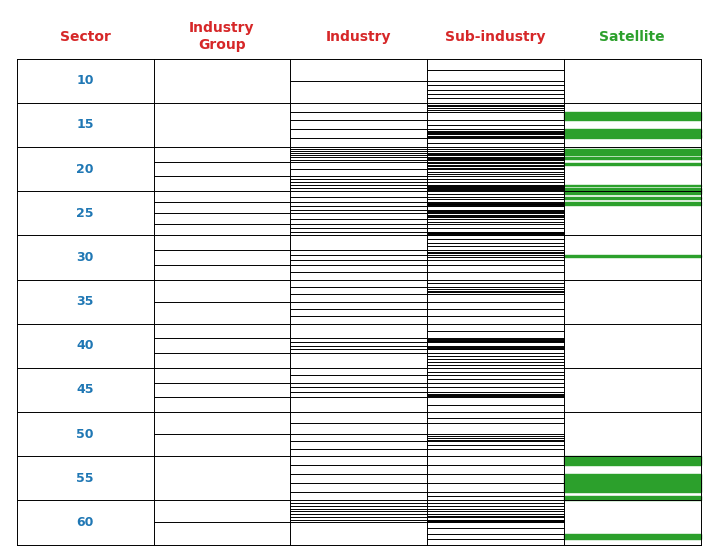

In [2]:
gics = sio.loadmat(f"{DATA_DIR}/chap11_gics_classification_2023.mat")
gics_code = gics["gics_code"].astype(np.int64)
satellite = gics["satellite"].ravel().astype(bool)


def stable_unique(a):
    seen, out = set(), []
    for v in a:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return np.array(out)


gics_code1 = stable_unique(gics_code[:, 0])
gics_code2 = stable_unique(gics_code[:, 1])
gics_code3 = stable_unique(gics_code[:, 2])
gics_code4 = stable_unique(gics_code[:, 3])
n1, n2, n3 = len(gics_code1), len(gics_code2), len(gics_code3)


def child_counts(child_codes, parent_codes, divisor):
    return np.array([np.sum(child_codes // divisor == p) for p in parent_codes])


gics_n1 = child_counts(gics_code2, gics_code1, 100)  # industry groups per sector
gics_n2 = child_counts(gics_code3, gics_code2, 100)  # industries per industry group
gics_n3 = child_counts(gics_code4, gics_code3, 100)  # sub-industries per industry

h = 110.0


def subdivide(y_boundaries, counts):
    out = []
    for j, z in enumerate(counts):
        y0, dy = y_boundaries[j], y_boundaries[j] - y_boundaries[j + 1]
        for i in range(int(z)):
            out.append(y0 - i * (dy / z))
    out.append(0.0)
    return np.array(out)


all_y1 = np.array([h * (n1 - j) / n1 for j in range(n1 + 1)])
all_y2 = subdivide(all_y1, gics_n1)
all_y3 = subdivide(all_y2, gics_n2)
all_y4 = subdivide(all_y3, gics_n3)

fig, ax = plt.subplots(figsize=(9, 7))


def hline(x0, x1, y):
    ax.plot([x0, x1], [y, y], "-", color="black", lw=0.7)


def vline(x, y0, y1):
    ax.plot([x, x], [y0, y1], "-", color="black", lw=0.7)


vline(1, 0, h)
for j in range(n1):
    hline(1, 2, all_y1[j])
    ax.text(1.5, h * (n1 - j - 0.5) / n1, str(gics_code1[j]), ha="center", va="center",
             color="tab:blue", fontsize=9, fontweight="bold")
hline(1, 2, 0)
vline(2, 0, h)

for j in range(n1):
    z, y0, dy = gics_n1[j], all_y1[j], all_y1[j] - all_y1[j + 1]
    for i in range(int(z)):
        hline(2, 3, y0 - i * (dy / z))
hline(2, 3, 0)
vline(3, 0, h)

for j in range(n2):
    z, y0, dy = gics_n2[j], all_y2[j], all_y2[j] - all_y2[j + 1]
    for i in range(int(z)):
        hline(3, 4, y0 - i * (dy / z))
hline(3, 4, 0)
vline(4, 0, h)

for j in range(n3):
    z, y0, dy = gics_n3[j], all_y3[j], all_y3[j] - all_y3[j + 1]
    for i in range(int(z)):
        hline(4, 5, y0 - i * (dy / z))
hline(4, 5, 0)
vline(5, 0, h)

for j in range(n1):
    hline(5, 6, all_y1[j])
hline(5, 6, 0)
vline(6, 0, h)

for j in range(len(satellite)):
    if satellite[j]:
        y1_, y2_ = all_y4[j], all_y4[j + 1]
        ax.fill([5, 6, 6, 5], [y1_, y1_, y2_, y2_], color="tab:green", edgecolor="tab:green")

for x, label in zip([1.5, 2.5, 3.5, 4.5], ["Sector", "Industry\nGroup", "Industry", "Sub-industry"]):
    ax.text(x, 115, label, ha="center", va="center", color="tab:red", fontsize=10, fontweight="bold")
ax.text(5.5, 115, "Satellite", ha="center", va="center", color="tab:green", fontsize=10, fontweight="bold")

ax.set_xlim(0.95, 6.05)
ax.set_ylim(-1, 121)
ax.axis("off")
plt.show()

## 2. Green bond vs. aggregate bond index

Monthly index level and portfolio duration of a Bloomberg MSCI Global
Green Bond index against the Bloomberg Global Aggregate benchmark,
2013-2023, plus the annualized tracking-error volatility between them.


TE(Green Bond | Aggregate) = 273.24 bps


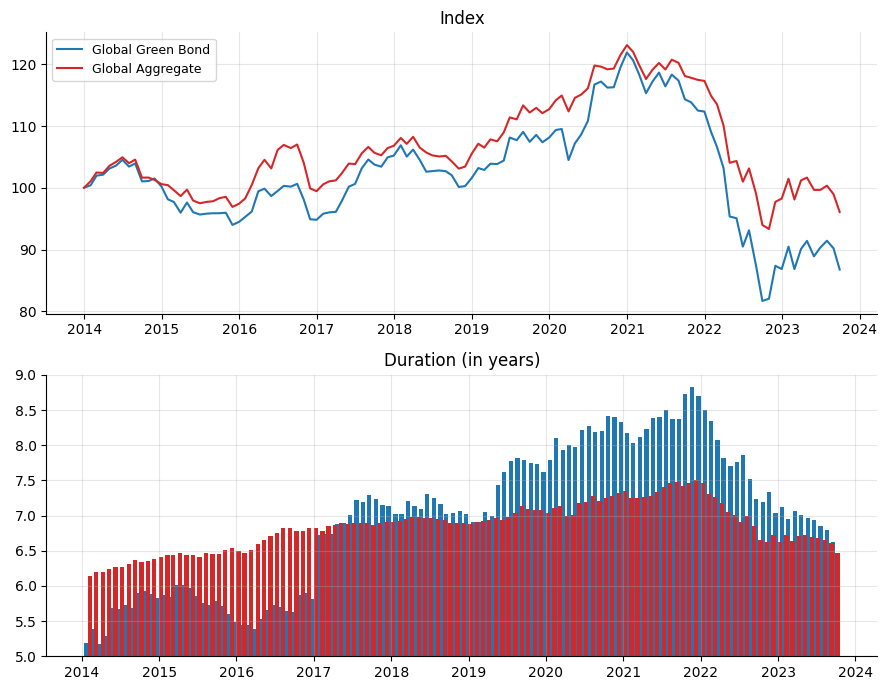

In [3]:
idx_df = pd.read_excel(f"{DATA_DIR}/chap11_green_bonds.xlsx", sheet_name="Index", skiprows=1,
                        names=["date", "green_bond", "aggregate"])
idx_df["date"] = pd.to_datetime(idx_df["date"])
dur_df = pd.read_excel(f"{DATA_DIR}/chap11_green_bonds.xlsx", sheet_name="Duration", skiprows=1,
                        names=["date", "green_bond", "aggregate"])
dur_df["date"] = pd.to_datetime(dur_df["date"])
duration = pd.concat([pd.DataFrame({"green_bond": [np.nan], "aggregate": [np.nan]}), dur_df[["green_bond", "aggregate"]]],
                      ignore_index=True)
dates14 = idx_df["date"].values
index14 = idx_df[["green_bond", "aggregate"]].values
duration14 = duration.values

R14 = index14[1:] / index14[:-1] - 1.0
TE14 = np.sqrt(12) * np.std(R14[:, 0] - R14[:, 1], ddof=1)
print(f"TE(Green Bond | Aggregate) = {1e4*TE14:.2f} bps")

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
axes[0].plot(dates14, index14[:, 0], "-", color="tab:blue", lw=1.5, label="Global Green Bond")
axes[0].plot(dates14, index14[:, 1], "-", color="tab:red", lw=1.5, label="Global Aggregate")
axes[0].set_title("Index")
axes[0].grid(True, alpha=0.3)

width_days = 20
width = np.timedelta64(width_days, "D")
axes[1].bar(dates14 - np.timedelta64(width_days // 2, "D"), duration14[:, 0], width=width, color="tab:blue", label="Global Green Bond")
axes[1].bar(dates14 + np.timedelta64(width_days // 2, "D"), duration14[:, 1], width=width, color="tab:red", label="Global Aggregate")
axes[1].set_ylim(5, 9)
axes[1].set_title("Duration (in years)")
axes[1].grid(True, alpha=0.3)

axes[0].legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## 3. Thematic equity fund tracking error

Daily indexed level (rebased to 100) and rolling 1-year (260 trading
day) tracking-error volatility of 4 thematic equity indices (Bloomberg
BioEnergy, Bloomberg Hydrogen, MSCI Future Mobility, MSCI New Energy)
against MSCI World, 2015-2023, plotted every 5th trading day.


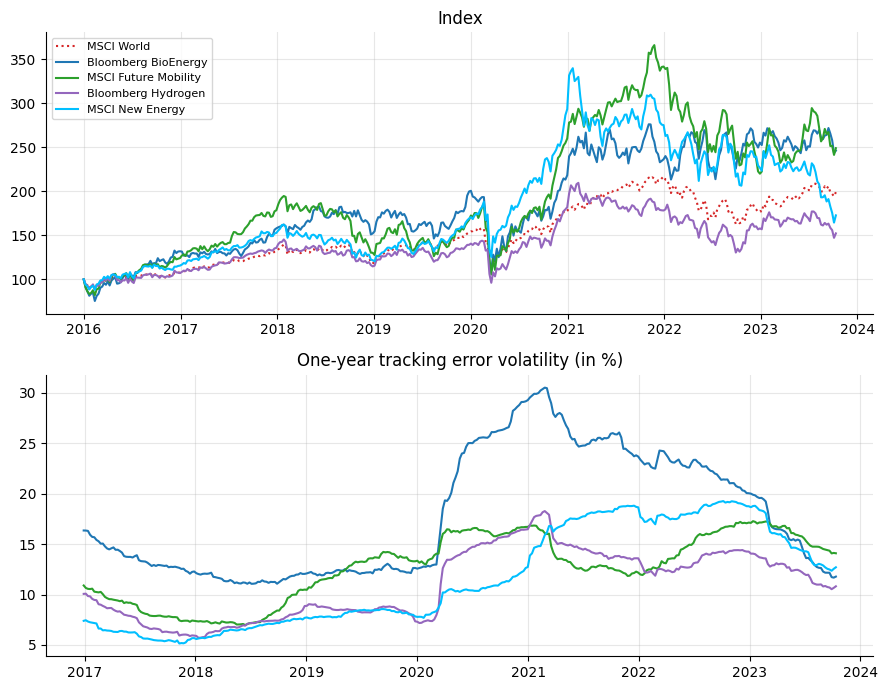

In [4]:
raw = pd.read_excel(f"{DATA_DIR}/chap11_thematic_equity_funds.xlsx", sheet_name="Feuil1", skiprows=1,
                     names=["date", "world", "bioenergy", "hydrogen", "future_mobility", "new_energy"])
raw["date"] = pd.to_datetime(raw["date"])
raw = raw[raw["date"] >= "2015-12-31"].reset_index(drop=True).ffill()

lgd_order = ["world", "bioenergy", "future_mobility", "hydrogen", "new_energy"]
lgd_label = ["MSCI World", "Bloomberg BioEnergy", "MSCI Future Mobility", "Bloomberg Hydrogen", "MSCI New Energy"]
dates15 = raw["date"].values
equity_data = raw[lgd_order].values
index15 = 100 * equity_data / equity_data[0, :]

nDates = len(index15)
R15 = index15[1:] / index15[:-1] - 1.0
R15 = np.vstack([np.full((1, 5), np.nan), R15])  # keep row alignment with index15/dates15

TE15 = np.full((nDates, 5), np.nan)
for t in range(260, nDates):
    for j in range(1, 5):
        e = R15[t - 259:t + 1, j] - R15[t - 259:t + 1, 0]
        e = e[~np.isnan(e)]
        TE15[t, j] = np.sqrt(260) * np.std(e, ddof=1)
TE15 = 100 * TE15

sel = np.arange(0, nDates, 5)
dates15_s, index15_s, TE15_s = dates15[sel], index15[sel], TE15[sel]

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
styles = [":", "-", "-", "-", "-"]
colors = ["tab:red", "tab:blue", "tab:green", "tab:purple", "deepskyblue"]
for j in range(5):
    axes[0].plot(dates15_s, index15_s[:, j], styles[j], color=colors[j], lw=1.5, label=lgd_label[j])
axes[0].set_title("Index")
axes[0].grid(True, alpha=0.3)

for j in range(5):
    axes[1].plot(dates15_s, TE15_s[:, j], styles[j], color=colors[j], lw=1.5, label=lgd_label[j])
axes[1].set_title("One-year tracking error volatility (in %)")
axes[1].grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()